In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
lexicon = pd.read_csv("/mnt/ssd_1/ivn/lm-confidence-evaluation-harness/linguistic_confidence_lexicon/hedging_word_scores.csv")
lexicon

,hedging_word,all_scores,count,mean,std,alpha_param,beta_param
0,I believe,"[0.78, 0.65, 0.65, 0.94, 0.84, 0.66, 0.81, 0.6...",180,0.782944,0.117708,6.880762,1.863562
1,I can assure you,"[0.94, 0.92, 0.98, 0.95, 0.85, 0.95, 0.99, 0.9...",180,0.940667,0.053682,20.899998,1.324237
2,I can confirm,"[0.98, 0.68, 0.94, 0.83, 0.9, 0.85, 0.99, 0.92...",180,0.931278,0.064610,13.881988,1.025243
3,I don't know,"[0.49, 0.25, 0.56, 0.58, 0.23, 0.22, 0.04, 0.4...",173,0.244798,0.160201,1.744848,5.074832
4,I firmly believe,"[0.95, 0.95, 0.98, 0.99, 0.91, 0.99, 0.98, 0.9...",180,0.934889,0.056994,13.692104,0.947368
...,...,...,...,...,...,...,...
138,very roughly,"[0.18, 0.76, 0.28, 0.32, 0.34, 0.69, 0.69, 0.8...",180,0.468778,0.221965,2.137168,2.378558
139,wildly guessing,"[0.16, 0.03, 0.26, 0.04, 0.04, 0.05, 0.45, 0.0...",165,0.226182,0.205180,0.985339,3.084981
140,without a doubt,"[0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.9...",180,0.989889,0.004713,125.495895,1.278231
141,without question,"[1.0, 1.0, 0.99, 0.99, 0.99, 1.0, 0.99, 0.99, ...",180,0.983056,0.032627,34.088162,0.600761


In [7]:
lexicon.columns

Index(['hedging_word', 'all_scores', 'count', 'mean', 'std', 'alpha_param',
       'beta_param'],
      dtype='str')

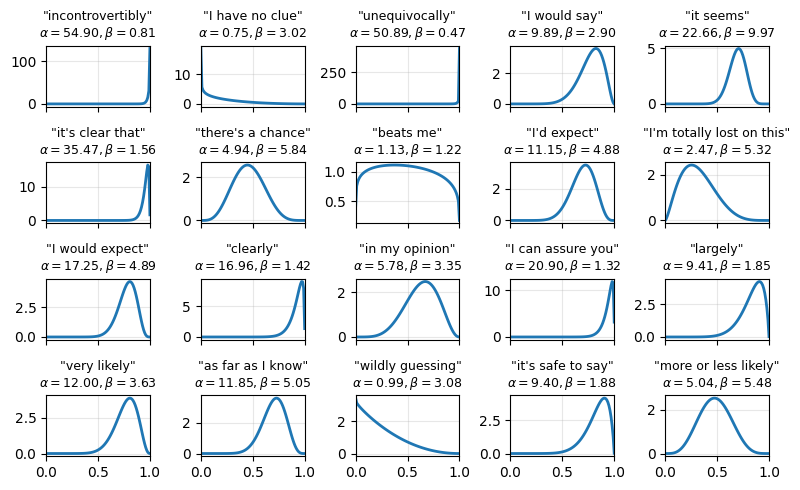

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from math import lgamma, exp

valid_lexicon = lexicon.dropna(subset=["hedging_word", "alpha_param", "beta_param"])

selected_words = ["maybe", "probably", "possibly", "could", "might", "uncertainty", "sure", "seems", "appears", 
                  "suggests", "indicates", "likely", "guess", "assume", "uncertain", "surely", 
                  "undoubtedly", "unquestionably", "hypothetically", "would appear to", "I am convinced",
                  "I am confident that", "I am doubtful", "plausibly", "speculatively"]

sampled = valid_lexicon.sample(n=25)

x = np.linspace(1e-4, 1 - 1e-4, 100)

def beta_pdf(x_vals, alpha, beta):
    # Beta(a, b) PDF = x^(a-1) * (1-x)^(b-1) / B(a, b)
    log_B = lgamma(alpha) + lgamma(beta) - lgamma(alpha + beta)
    return (x_vals ** (alpha - 1)) * ((1 - x_vals) ** (beta - 1)) / exp(log_B)

fig, axes = plt.subplots(4, 5, figsize=(8, 5), sharex=True)
axes = axes.flatten()

for ax, row in zip(axes, sampled.itertuples(index=False)):
    a = float(row.alpha_param)
    b = float(row.beta_param)
    y = beta_pdf(x, a, b)

    ax.plot(x, y, linewidth=2)
    ax.set_title(f""""{row.hedging_word}"\n""" + rf"""$\alpha={a:.2f}, \beta={b:.2f}$""", fontsize=9)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

for ax in axes[len(sampled):]:
    ax.axis("off")

# fig.suptitle("Beta Distributions for Randomly Sampled Hedging Words", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("figs/hedging_word_beta_distributions.pdf", dpi=300, bbox_inches="tight")